In [1]:

# Importing required libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Loading the dataset
df = pd.read_csv("netflix.csv")


type
Movie      6131
TV Show    2676
Name: count, dtype: int64


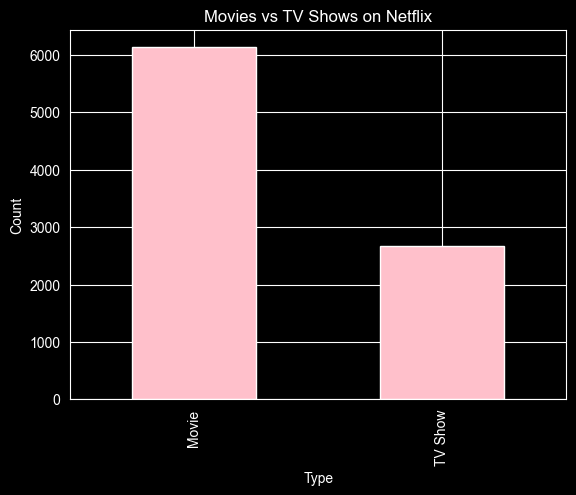

In [2]:
#Business-Oriented Analysis Questions

#1. Content Strategy

#1. What is the ratio of Movies vs TV Shows on Netflix?
type_count = df['type'].value_counts()

print(type_count)

type_count.plot(kind='bar',color='pink')
plt.title("Movies vs TV Shows on Netflix")
plt.xlabel("Type")
plt.ylabel("Count")
plt.show()

#Insight
#Netflix has more Movies than TV Shows.
#This shows Netflix focuses more on movie content production.

 International Movies     2624
Dramas                    1600
Comedies                  1210
Action & Adventure         859
Documentaries              829
 Dramas                    827
International TV Shows     774
 Independent Movies        736
 TV Dramas                 696
 Romantic Movies           613
Name: count, dtype: int64


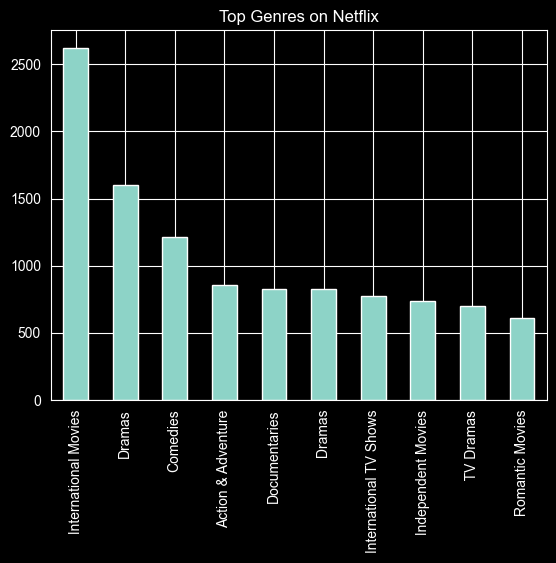

In [3]:
#2. Which genres are most popular on Netflix globally?
genres = df['listed_in'].str.split(',', expand=True)
all_genres = pd.Series(genres.values.ravel())
genre_count = all_genres.value_counts().head(10)
print(genre_count)
genre_count.plot(kind='bar')
plt.title("Top Genres on Netflix")
plt.show()

#Insight
#Drama, Comedy, and International Movies are the most common genres.
#These genres are highly popular among viewers.

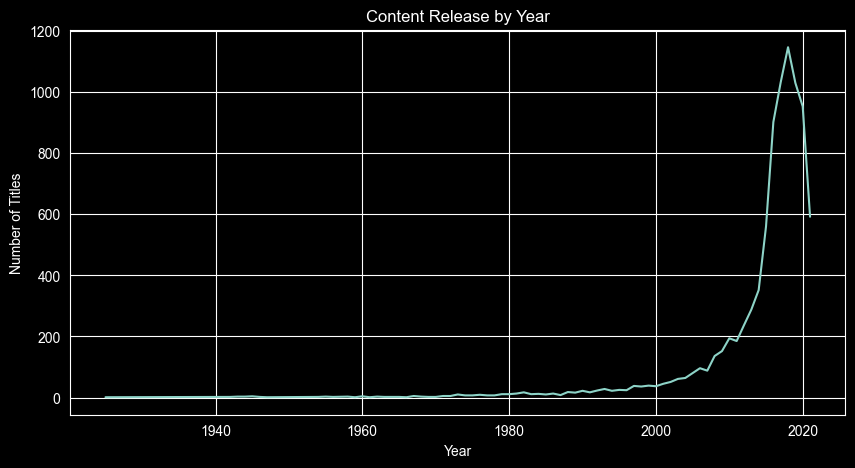

In [10]:
#3. Which years saw the highest release of content on Netflix?
year_count = df['release_year'].value_counts().sort_index()
plt.figure(figsize=(10,5))
year_count.plot()
plt.title("Content Release by Year")
plt.xlabel("Year")
plt.ylabel("Number of Titles")
plt.show()

#Insight
#The number of releases increased after 2015.
#Netflix started adding more content in recent years.

country
United States     2818
India              972
United Kingdom     419
Japan              245
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Egypt              106
Name: count, dtype: int64


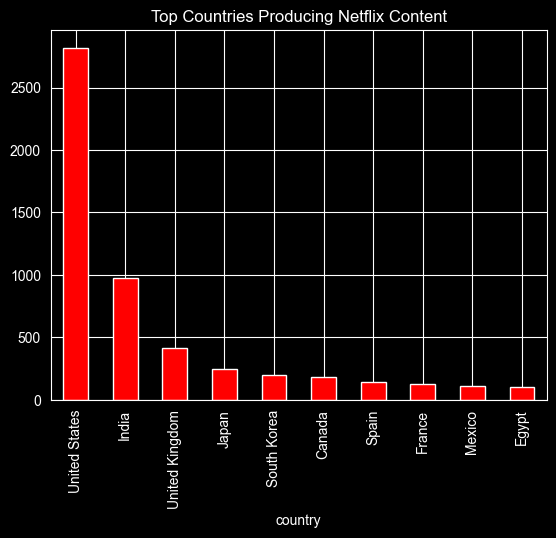

In [12]:
#4Which countries produce the most Netflix content?
country_count = df['country'].value_counts().head(10)
print(country_count)
country_count.plot(kind='bar',color='red')
plt.title("Top Countries Producing Netflix Content")
plt.show()

#Insight
#United States produces the highest content.
#Other important countries include India, UK, and Canada.

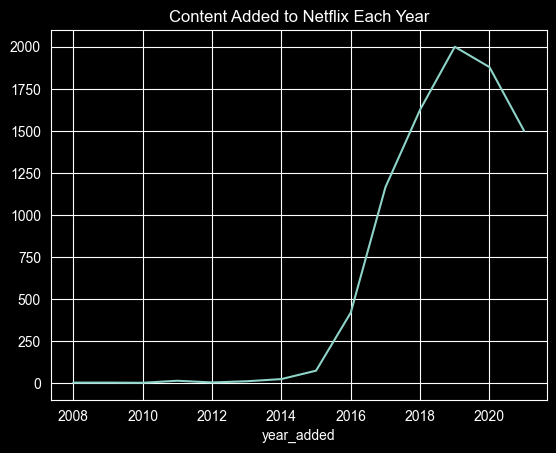

In [13]:
#5. How has the trend of adding new content evolved year by year?
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
df['year_added'] = df['date_added'].dt.year
year_added_count = df['year_added'].value_counts().sort_index()
year_added_count.plot()
plt.title("Content Added to Netflix Each Year")
plt.show()

#Insight
#Netflix added maximum content between 2018 and 2020.
#This indicates rapid platform growth during that period.

rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64


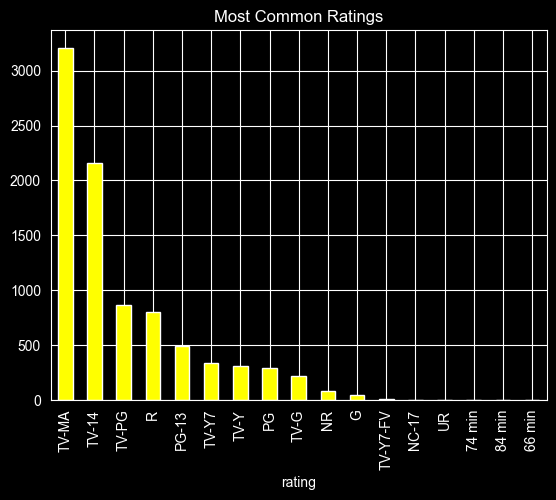

In [14]:
#2. User Demographics & Targeting

#6. Which ratings (e.g., TV-MA, PG, etc.) are most frequent on Netflix?
rating_count = df['rating'].value_counts()
print(rating_count)
rating_count.plot(kind='bar',color='yellow')
plt.title("Most Common Ratings")
plt.show()

#Insight
#TV-MA rating appears most frequently.
#This means Netflix content is mostly targeted towards adult audiences.

country
United States     928
India             248
United Kingdom    177
Spain             119
Japan              87
South Korea        85
France             80
Mexico             77
Turkey             63
Canada             61
Name: count, dtype: int64


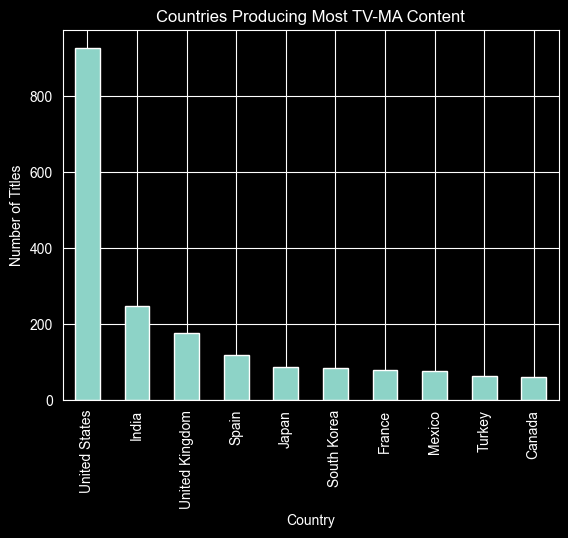

In [16]:
#7. Do some countries tend to produce more mature content (TV-MA)?
# Filtering only TV-MA rated content
tvma_content = df[df['rating'] == 'TV-MA']
# Counting countries that produce TV-MA content
tvma_country = tvma_content['country'].value_counts().head(10)

print(tvma_country)
# Plotting graph
tvma_country.plot(kind='bar')
plt.title("Countries Producing Most TV-MA Content")
plt.xlabel("Country")
plt.ylabel("Number of Titles")
plt.show()

#Insight
#United States produces the most TV-MA rated content.
#Some other countries also create mature content.
#This shows Netflix targets adult audiences in many regions.

In [17]:
#8.Which genres are more associated with TV Shows vs Movies?
movie_genres = df[df['type']=='Movie']['listed_in'].value_counts().head(5)
tv_genres = df[df['type']=='TV Show']['listed_in'].value_counts().head(5)
print("Top Movie Genres")
print(movie_genres)
print("Top TV Show Genres")
print(tv_genres)

#Insight
#Movies mostly include Drama and International Movies.
#TV Shows often include TV Dramas and Crime Shows.

Top Movie Genres
listed_in
Dramas, International Movies                        362
Documentaries                                       359
Stand-Up Comedy                                     334
Comedies, Dramas, International Movies              274
Dramas, Independent Movies, International Movies    252
Name: count, dtype: int64
Top TV Show Genres
listed_in
Kids' TV                                             220
International TV Shows, TV Dramas                    121
Crime TV Shows, International TV Shows, TV Dramas    110
Kids' TV, TV Comedies                                 99
Reality TV                                            95
Name: count, dtype: int64


In [18]:
#9. Which genres dominate the U.S. vs other countries?
# Filtering content from United States
us_content = df[df['country'].str.contains('United States', na=False)]
# Filtering content from other countries
other_content = df[~df['country'].str.contains('United States', na=False)]
# Top genres in US
us_genres = us_content['listed_in'].value_counts().head(5)
print("Top Genres in U.S.")
print(us_genres)
# Top genres in Other Countries
other_genres = other_content['listed_in'].value_counts().head(5)
print("Top Genres in Other Countries")
print(other_genres)

#Insight
#In the U.S., Drama and Comedy genres are most common.
#In other countries, International Movies and Dramas dominate.
#This shows content preferences vary across regions.

Top Genres in U.S.
listed_in
Documentaries                         289
Stand-Up Comedy                       210
Children & Family Movies, Comedies    146
Kids' TV                              119
Dramas                                115
Name: count, dtype: int64
Top Genres in Other Countries
listed_in
Dramas, International Movies                        346
Comedies, Dramas, International Movies              269
Dramas, Independent Movies, International Movies    229
Dramas, International Movies, Romantic Movies       178
Comedies, International Movies                      173
Name: count, dtype: int64


listed_in
Stand-Up Comedy                 101
Dramas, International Movies     87
Documentaries                    76
Children & Family Movies         76
Kids' TV                         74
Name: count, dtype: int64


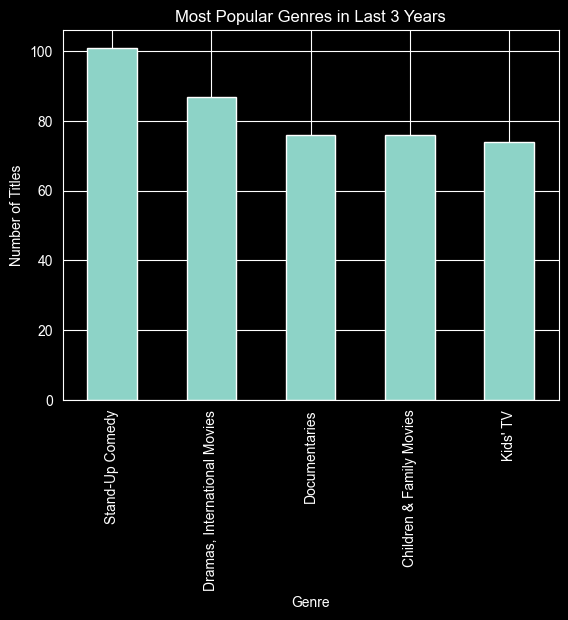

In [19]:
#10.What genres are most popular in the last 3 years?
# Finding the latest year in the dataset
latest_year = df['release_year'].max()

# Filtering data for last 3 years
recent_data = df[df['release_year'] >= latest_year - 2]

# Counting most common genres
recent_genres = recent_data['listed_in'].value_counts().head(5)
print(recent_genres)

# Plot
recent_genres.plot(kind='bar')
plt.title("Most Popular Genres in Last 3 Years")
plt.xlabel("Genre")
plt.ylabel("Number of Titles")
plt.show()

#Insight
#In the last 3 years, Drama and Comedy remain the most popular genres.
#This shows these genres continue to attract more viewers on Netflix.

director
Rajiv Chilaka             19
Raúl Campos, Jan Suter    18
Suhas Kadav               16
Marcus Raboy              16
Jay Karas                 14
Cathy Garcia-Molina       13
Youssef Chahine           12
Martin Scorsese           12
Jay Chapman               12
Steven Spielberg          11
Name: count, dtype: int64


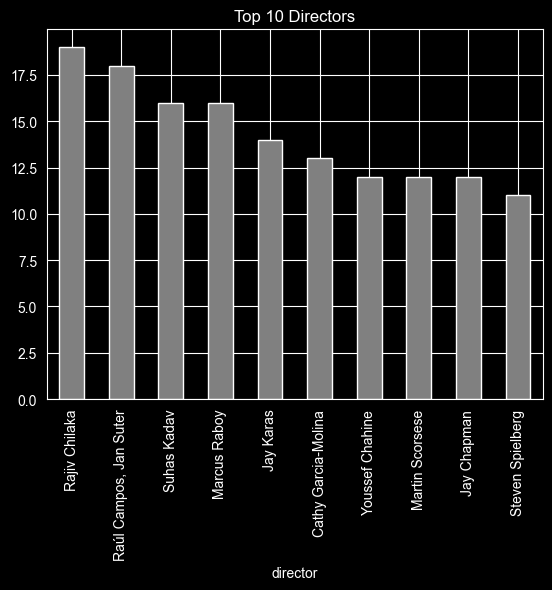

In [21]:
#3. Talent Acquisition & Partnerships

#11. Who are the top 10 directors with the most Netflix content?
director_count = df['director'].value_counts().head(10)
print(director_count)
director_count.plot(kind='bar',color='grey')
plt.title("Top 10 Directors")
plt.show()

#Insight
#Some directors appear multiple times.
#Netflix often collaborates with frequent content creators.

In [22]:
#12.Which actors appear most frequently in Netflix shows?
actors = df['cast'].str.split(',', expand=True)
all_actors = pd.Series(actors.values.ravel())
actor_count = all_actors.value_counts().head(10)
print(actor_count)

#Insight
#Some actors appear in multiple Netflix titles.
#Popular actors may help attract viewers.

 Anupam Kher         39
 Rupa Bhimani        31
 Takahiro Sakurai    30
 Julie Tejwani       28
 Om Puri             27
 Rajesh Kava         26
Shah Rukh Khan       26
 Andrea Libman       25
 Yuki Kaji           25
 Boman Irani         25
Name: count, dtype: int64


In [23]:
#13.Which director-genre pairs are most frequent?
# Selecting required columns and removing missing values
data = df[['director', 'listed_in']].dropna()

# Counting director and genre combinations
director_genre = data.groupby(['director', 'listed_in']).size().sort_values(ascending=False).head(10)

print(director_genre)

#Insight
#Some directors frequently work in specific genres.
#This shows directors often specialize in particular types of content like Drama or Comedy.

director                listed_in                                       
Raúl Campos, Jan Suter  Stand-Up Comedy                                     18
Rajiv Chilaka           Children & Family Movies                            18
Marcus Raboy            Stand-Up Comedy                                     15
Jay Karas               Stand-Up Comedy                                     13
Jay Chapman             Stand-Up Comedy                                     11
Shannon Hartman         Stand-Up Comedy                                      8
S.S. Rajamouli          Action & Adventure, Dramas, International Movies     7
Hidenori Inoue          Action & Adventure, Dramas, International Movies     7
Prakash Satam           Children & Family Movies, Comedies                   7
Ryan Polito             Stand-Up Comedy                                      7
dtype: int64


In [24]:
#14.How many titles have unknown directors or cast members?
unknown_director = df['director'].isnull().sum()
unknown_cast = df['cast'].isnull().sum()

print("Unknown Directors:", unknown_director)
print("Unknown Cast:", unknown_cast)

#Insight
#Some titles do not have director or cast information.
#These missing values may affect data analysis.

Unknown Directors: 2636
Unknown Cast: 827


In [25]:
#4. Duration & Engagement

#15. What is the average duration of Movies on Netflix?
movies = df[df['type']=='Movie']
movies['duration'] = movies['duration'].str.replace(' min','')
movies['duration'] = movies['duration'].astype(float)
avg_duration = movies['duration'].mean()
print("Average Movie Duration:", avg_duration)

#Insight
#Average movie duration is around 90–100 minutes.
#This seems to be the optimal length for movies.

Average Movie Duration: 99.57718668407311


In [26]:
#16. What’s the most common number of seasons for TV shows?
tvshows = df[df['type']=='TV Show']
season_count = tvshows['duration'].value_counts().head()
print(season_count)

#Insight
#Most TV shows have 1 or 2 seasons.
#Long-running shows are fewer.

duration
1 Season     1793
2 Seasons     425
3 Seasons     199
4 Seasons      95
5 Seasons      65
Name: count, dtype: int64


release_year
1942.0    35.000000
1943.0    62.666667
1944.0    52.000000
1945.0    51.333333
1946.0    58.000000
            ...    
2017.0    95.535248
2018.0    96.185137
2019.0    93.466035
2020.0    92.141199
2021.0    96.444043
Name: duration, Length: 73, dtype: float64


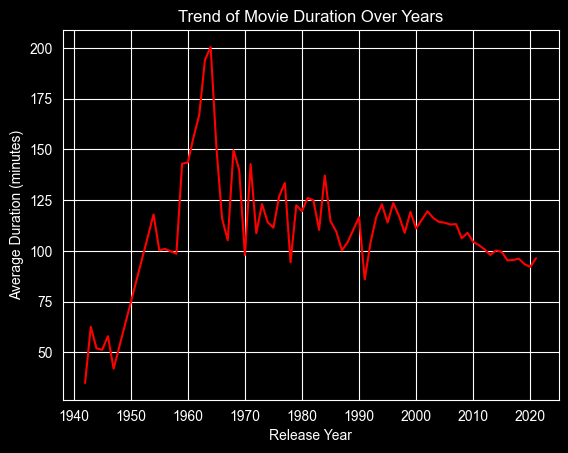

In [30]:
#17. Is there a trend in movie durations over the years?
# Selecting only movies
movies = df[df['type'] == 'Movie']

# Cleaning duration column
movies['duration'] = movies['duration'].str.replace(' min','')
movies['duration'] = movies['duration'].astype(float)

# Average duration per year
duration_trend = movies.groupby('release_year')['duration'].mean()
print(duration_trend)

# Plotting
duration_trend.plot(color='red')
plt.title("Trend of Movie Duration Over Years")
plt.xlabel("Release Year")
plt.ylabel("Average Duration (minutes)")
plt.show()

#Insight
#Movie duration has remained almost consistent over the years.
#Most movies are around 90–100 minutes long.

month_added
1.0     727
2.0     557
3.0     734
4.0     759
5.0     626
6.0     724
7.0     819
8.0     749
9.0     765
10.0    755
11.0    697
12.0    797
Name: count, dtype: int64


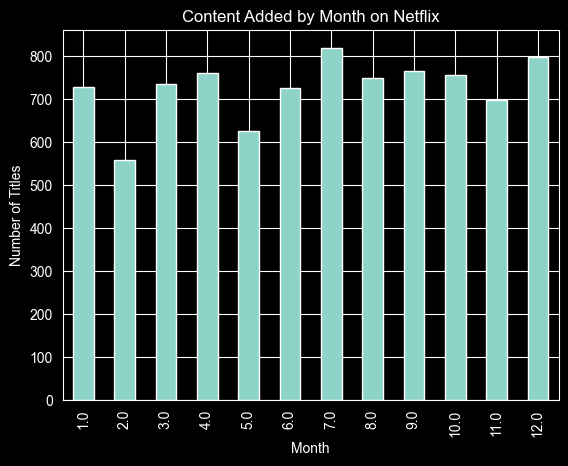

In [34]:
#5. Content Launch Strategy

#18.In which months does Netflix add the most content?
# Convert date_added column to datetime
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

# Extract month
df['month_added'] = df['date_added'].dt.month

# Count content added each month
month_count = df['month_added'].value_counts().sort_index()
print(month_count)

# Plot graph
month_count.plot(kind='bar')
plt.title("Content Added by Month on Netflix")
plt.xlabel("Month")
plt.ylabel("Number of Titles")
plt.show()

#Insight
#Netflix adds more content in some specific months.
#This may be done to attract more viewers during peak periods.

   release_year                      listed_in  count
0        1925.0                       TV Shows      1
1        1942.0  Classic Movies, Documentaries      2
2        1943.0  Classic Movies, Documentaries      1
3        1943.0                  Documentaries      2
4        1944.0  Classic Movies, Documentaries      3


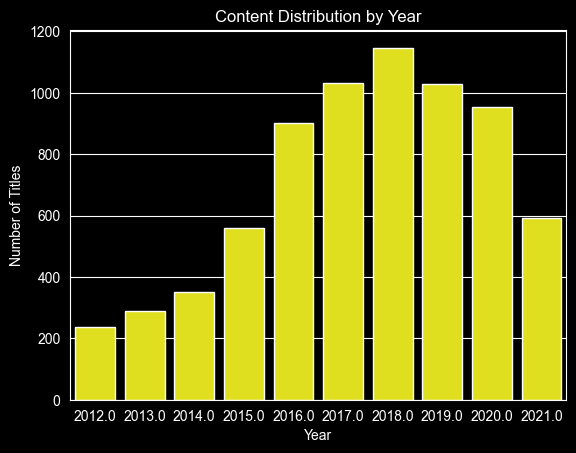

In [36]:
#19. How does the genre distribution vary across different years?
# Genre distribution by year
genre_year = df.groupby(['release_year', 'listed_in']).size().reset_index(name='count')

# Showing first few rows
print(genre_year.head())

# Plotting top years with most content
top_years = df['release_year'].value_counts().head(10).index

data = df[df['release_year'].isin(top_years)]

sns.countplot(data=data, x='release_year',color='yellow')
plt.title("Content Distribution by Year")
plt.xlabel("Year")
plt.ylabel("Number of Titles")
plt.show()

#Insight
#Different genres become popular in different years.
#Drama and Comedy remain popular across most years.

In [37]:
#20. Which countries produce the most content in each genre?
# Selecting required columns and removing missing values
data = df[['country','listed_in']].dropna()

# Counting country and genre combinations
country_genre = data.groupby(['country','listed_in']).size().sort_values(ascending=False).head(10)
print(country_genre)

#Insight
#United States produces the most content in many genres.
#Other countries also contribute to specific genres.
#This shows Netflix content comes from multiple regions worldwide.

country        listed_in                                       
United States  Documentaries                                       249
               Stand-Up Comedy                                     209
India          Comedies, Dramas, International Movies              120
               Dramas, International Movies                        118
               Dramas, Independent Movies, International Movies    108
United States  Children & Family Movies, Comedies                   90
               Dramas                                               88
               Comedies                                             84
               Children & Family Movies                             80
               Kids' TV                                             77
dtype: int64
